In [23]:
#---importing module dependencies-----
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

In [24]:
#----setting the plot style to ggplot----
plt.style.use('ggplot')

In [25]:
#----loading the breats cancer data----
b_cancer = load_breast_cancer()

In [26]:
#----trandform the data into a panda DataFrame and slicing out the first six columns/features---
df = pd.DataFrame(data=b_cancer.data,
                  columns=b_cancer.feature_names)


In [27]:
#------Making an exploratory data analysis-------

In [28]:
#----checking the sructure of the df---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [29]:
#---The dataset includes various information about breast cancer tumors, as well as classification labels of malignant or
#benign. It also has 569 instances/observations on 569 tumors and includes information on 30 attributes/ features, such as the radius of the tumor
#texture, smoothness and area.

In [30]:
#------loading summary stats of the df----
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [31]:
#--- viewing the first six rows of the df---
df.iloc[:, 0:6].head(6)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280
5,12.45,15.70,82.57,477.1,0.12780,0.17000


In [32]:
#----inspecting feature colinearlity---
(df.iloc[:, 0:6].head(6)).corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
mean radius,1.000000,-0.168256,0.996571,0.998340,-0.907256,-0.606145
mean texture,-0.168256,1.000000,-0.216754,-0.141072,0.107054,-0.188851
mean perimeter,0.996571,-0.216754,1.000000,0.991710,-0.874784,-0.544759
mean area,0.998340,-0.141072,0.991710,1.000000,-0.921359,-0.637563
mean smoothness,-0.907256,0.107054,-0.874784,-0.921359,1.000000,0.835522
mean compactness,-0.606145,-0.188851,-0.544759,-0.637563,0.835522,1.000000


In [33]:
covariance = (df.iloc[:, 0:6].head(6)).cov()
covariance

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
mean radius,16.719217,-2.784047,107.016503,1702.787333,-0.075757,-0.202082
mean texture,-2.784047,16.375547,-23.035553,-238.128533,0.008847,-0.062310
mean perimeter,107.016503,-23.035553,689.714177,10864.080667,-0.469161,-1.166494
mean area,1702.787333,-238.128533,10864.080667,173999.322667,-7.848542,-21.684073
mean smoothness,-0.075757,0.008847,-0.469161,-7.848542,0.000417,0.001391
mean compactness,-0.202082,-0.062310,-1.166494,-21.684073,0.001391,0.006648


<Axes: >

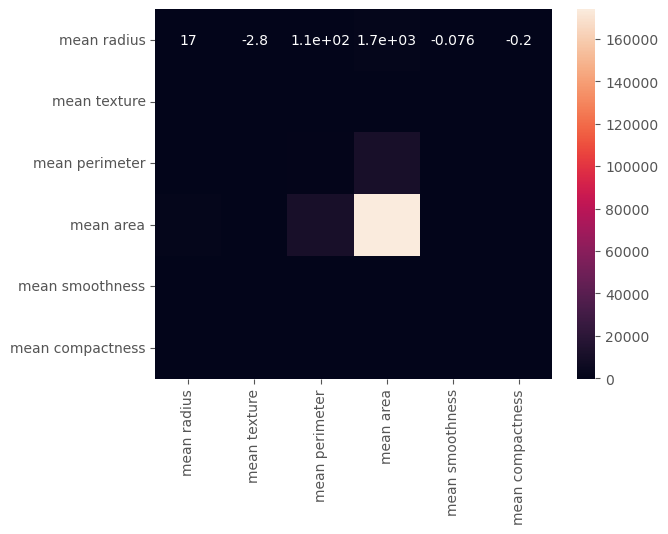

In [34]:
#---visualizing the covariance matric on a heat map---
sns.heatmap(covariance,annot =True)

In [35]:
#-----standardizing and transforming the data------
scaler = StandardScaler()
scaler.fit(df)
b_cancer_scaled = scaler.transform(df)

In [36]:
#-----loading the PCA model and fitting the b_cancer data----
pca = PCA(n_components=3)
pca.fit(b_cancer_scaled)
pca_b_cancer = pca.transform(b_cancer_scaled)


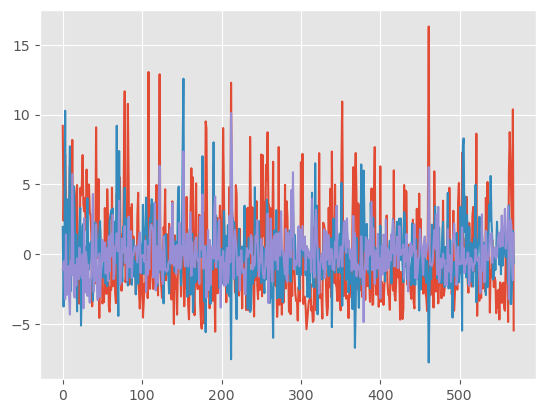

In [37]:
#---visualizing the PCA model---
plt.plot(pca_b_cancer)

In [38]:
#----Now creating a 3D plot of the PCA Model

In [39]:
#---definig the PCA 3d attributes/components--
Xax = pca_b_cancer[:,0]
Yax = pca_b_cancer[:,1]
Zax = pca_b_cancer[:,2]

In [40]:
#---extracting the diagnosis clasification target and definding labels refering to the diagnosis and point colors----
cdict = {0:'m', 1:'c'}
label = {0:'Malignant', 1:'Benign'}

y = b_cancer.target

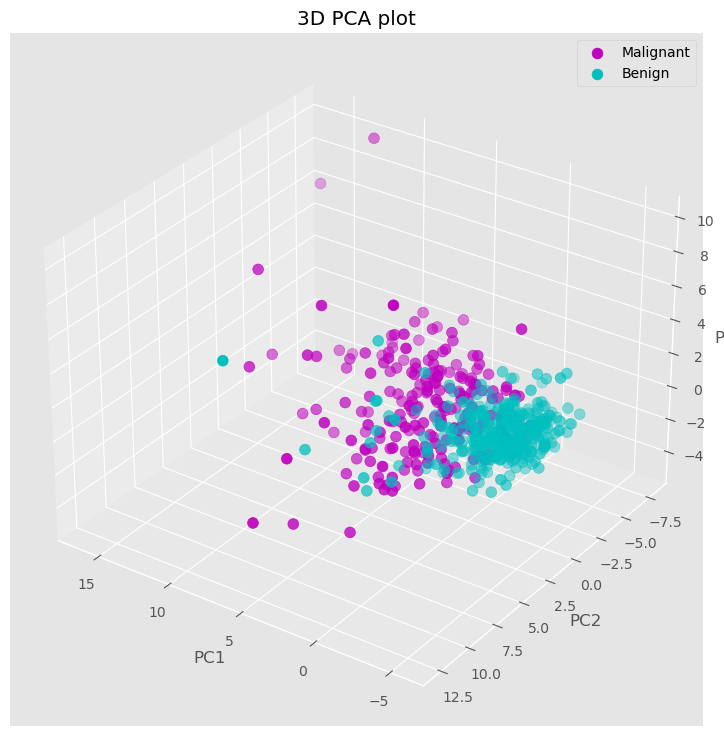

In [41]:
fig = plt.figure(figsize=(14,9))
ax = fig.add_subplot(111,
                     projection='3d')
for l in np.unique(y):
    ix = np.where(y==l)
    ax.scatter(Xax[ix],
               Yax[ix],
               Zax[ix],
               c=cdict[l],
               s=60,
               label=label[l])
ax.set_xlabel('PC1',
              fontsize=12)
ax.set_ylabel('PC2',
              fontsize=12)
ax.set_zlabel('PC3',
              fontsize=12)
ax.view_init(30, 125)
ax.legend()
plt.title('3D PCA plot')
plt.show()
      

In [42]:
#-----Now that the principal components have been chosen and visualized, the next step is to build a Naive Bayes model

In [49]:
##-reorganizing the data 
data = load_breast_cancer()
label_names = data['target_names']
labels = data['target']
features = data['data']
feature_names = data['feature_names']


In [69]:
#----now that we have the list of information about the data, we can now view the data by printing our class labels.
print('The labels names are:',label_names)

The labels names are: ['malignant' 'benign']


In [66]:
print( 'the target \n labels are:', labels)

the target 
 labels are: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1


In [67]:
print('breats cancer features:', features)

breats cancer features: [[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


In [68]:
print('breat cancer \n feature names:',feature_names)

breat cancer 
 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [70]:
#--spliting the data int oa training and testing sets
from sklearn.model_selection import train_test_split

In [71]:
#--spliting the data into a 67% training and 33% testing witha random state at 42
train, test, train_labels, test_labels = train_test_split(features, labels, test_size = 0.33, random_state = 42)

In [72]:
#--training the Bayesian model
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [74]:
#--now training our clasiisfication model
model = gnb.fit(train,train_labels)

In [75]:
#printint the fitted model
print('NaiveBayes_model:', model)

NaiveBayes_model: GaussianNB()


In [76]:
##--making predictions wiuth the model
pred = gnb.predict(test)

In [77]:
print('the predicted \n samples are:', pred)

the predicted 
 samples are: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0
 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0
 0 1 1]


In [80]:
#---evaluating the model performance
from sklearn.metrics import accuracy_score
print('the accuracy score is \n: ''',accuracy_score(test_labels, pred))

the accuracy score is 
:  0.9414893617021277


In [81]:
#the model is 94.15% accurately, this emplies that the model is 94.15% times able to make correct predictions on the breast cancer data
#as to whether a tumor is malignant or benign. indicating that the feature set of 3o attributes are good indicator for tumor class.